In [1]:
import pandas as pd
import os
import numpy as np
import astropy.units as u
from astropy.constants import M_jup, M_earth
import astropy.units as u
import matplotlib.pyplot as plt

import matplotlib 
import matplotlib.pyplot as plt
matplotlib.rc('xtick', labelsize=18) 
matplotlib.rc('ytick', labelsize=18) 
matplotlib.rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
matplotlib.rc('text', usetex=True)




In [2]:
sample_sources_w_mass_radius = pd.read_csv('./outputs/data/stars.csv')
sample_sources_w_mass_radius

/var/folders/9z/bcj7jltn3x5_8y20r9cxql3h0000gn/T/ipykernel_48632/2743170194.py:1: DtypeWarning: Columns (0: fit_success_binary_msms, 1: fit_success_single_msms, 2: flag_extrap_m2_msms) have mixed types. Specify dtype option on import or set low_memory=False.
  sample_sources_w_mass_radius = pd.read_csv('./outputs/data/stars.csv')


,gaia_source_id,source_id_dr2,hip_id,ra,dec,ra_error,dec_error,parallax,radial_velocity,pmra_hip,...,predicted_class_msms,q_binary_msms,ra_msms,radial_velocity_msms,radial_velocity_error_msms,astrometric_chi2_al_dr3,parallax_error,abs_G,mass_interp,radius_interp
0,5479559378348931200,5479559378348931200,NaN,104.451569,-60.372920,0.017413,0.017271,9.163278,31.439222,NaN,...,1.0,0.367839,104.451569,31.439222,5.467342,352.30774,0.018659,9.517337,0.416070,0.431044
1,5481069145252396928,5481069145252396928,NaN,94.501858,-61.931762,0.019870,0.017888,10.807500,72.872055,NaN,...,0.0,0.100000,94.501858,72.872055,4.053698,337.33606,0.018703,10.095283,0.364478,0.357631
2,5481478983915584256,5481478983915584256,NaN,95.883588,-61.539116,0.099535,0.093117,12.664252,13.964805,NaN,...,1.0,0.867628,95.883588,13.964805,1.014977,29628.98800,0.094480,8.248793,0.560486,0.574047
3,5481618557469377408,5481618557469377408,NaN,97.669544,-60.554270,0.015607,0.015902,5.860141,26.489969,NaN,...,1.0,0.614483,97.669544,26.489970,3.861051,324.32617,0.015685,8.568322,0.526492,0.529479
4,5482185145257567232,5482185145257567232,NaN,93.728649,-60.655343,0.014073,0.013951,26.065368,24.997168,NaN,...,1.0,0.630524,93.728649,24.997168,0.567186,727.13513,0.014611,8.579698,0.525295,0.528192
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10662,6879764552737781888,6879764552737781888,99572.0,303.108674,-12.618367,0.034322,0.019407,35.418534,27.201628,192.187363,...,NaN,NaN,NaN,NaN,NaN,1666.47230,0.035101,3.468151,1.274493,1.393903
10663,6881507171289815808,6881507171289815808,NaN,314.966530,-19.270865,0.494852,0.328530,5.787716,-22.518469,NaN,...,NaN,NaN,NaN,NaN,NaN,166320.10000,0.587363,8.769341,0.505333,0.506732
10664,6891134705556330880,6891134705556330880,106147.0,322.516126,-12.511222,0.020525,0.016549,56.426457,-84.689545,1017.014771,...,NaN,NaN,NaN,NaN,NaN,825.46310,0.023555,7.297645,0.664760,0.649312
10665,6905063765533078272,6905063765535544832,NaN,308.194628,-8.897616,0.062833,0.047892,10.033755,-32.714832,NaN,...,NaN,NaN,NaN,NaN,NaN,1587.22190,0.069177,5.890081,0.813505,0.778453


In [3]:
def near_first_order_resonance(a1, a2, j, tol=0.02):
    """
    Flag proximity to (j+1):j resonance.

    Parameters
    ----------
    tol : fractional tolerance (e.g. 0.01–0.05)

    Notes
    -----
    This is a selection criterion, not a dynamical stability condition. 
    
    It estimates based on an integer j, whether you are within decimal tol 
    of j+1/j first-order resonance.

    """
    P_ratio = (a2 / a1) ** 1.5
    target = (j + 1) / j
    return abs(P_ratio / target - 1) < tol

def classify_with_resonance(mu1, mu2, a1, a2, e1, e2):
    # 1. Orbit crossing → always unstable
    if a1*(1+e1) >= a2*(1-e2):
        return "unstable"

    # 2. Hill spacing
    RH = ((mu1+mu2)/3)**(1/3)*(a1+a2)/2
    delta = (a2-a1)/RH

    # 3. Check near resonance (2:1 and 3:2 only for now)
    near_res = (
        near_first_order_resonance(a1, a2, j=1) or
        near_first_order_resonance(a1, a2, j=2)
    )

    if delta < 3.5:
        if near_res:
            return "resonant_stable_possible"
        else:
            return "likely_unstable"

    return "stable"

In [18]:

M_JUP_IN_MSUN = 9.5458e-4
def semimajor_axis_to_period(a_au, mstar_msun):
    """Kepler's third law: P [yr] from a [AU] and M_star [Msun]."""
    return np.sqrt(a_au**3 / mstar_msun)

def gen_orbits_csv(star_catalog_path, output_dir, output_file, filter_snr=False, n_planets=1,  max_retries=1000, seed=42):
    '''
    Generates a CSV with 1 or 2 mock planets for real Gaia stars.
    Stability criterion for 2 planet systems must be met.

    Parameters:
    star_catalog_path : str
        Path to Gaia star catalog file.
    output_dir : str
        Directory for the output CSV. Created if it doesn't exist.
    output_file : str
        Filename for the output CSV.
    filter_snr : bool, optional
        If True, apply SNR-based rejection sampling. Default is False.
    n_planets : int, optional
        1 or 2. Default is 1.
    batch_size : int, optional
        Proposal pool size per iteration (only matters when rejection
        sampling is active). Default is 50000.


    Returns:
    csv_data : pandas.DataFrame
    '''
    M_mars_Mjup = (0.107 * M_earth).to(u.M_jup).value
    T_BASELINE = 24.75
    M_jup_per_Msun = M_jup.to(u.M_sun).value
    rng = np.random.default_rng(seed)
    os.makedirs(output_dir, exist_ok=True)

    catalog = pd.read_csv(star_catalog_path)
    n_stars = len(catalog)
    source_ids = catalog['gaia_source_id'].values
    mstar_arr = catalog['mass_interp'].values

    # SNR (only needed if filter_snr)
    if filter_snr:
        ms = mstar_arr
        sa = 10**rng.uniform(np.log10(1), np.log10(100), size=len(mstar_arr))
        ma = 10**rng.uniform(np.log10(M_mars_Mjup), np.log10(80), size=len(mstar_arr))
        sc = (T_BASELINE**2 * ms)**(1/3)
        snr = (ma / ms) * sa / (1.0 + (sa /sc)**3)
        snr_max_global = snr.max()

    def _draw_one_planet(mstar, n=1):
        """Draw sma, mass for one planet (with optional SNR rejection)."""
        if filter_snr:
            sma_crit = (T_BASELINE**2 * mstar)**(1/3)
            while True:
                sma = 10**rng.uniform(np.log10(1), np.log10(100), size=n)
                mass = 10**rng.uniform(np.log10(M_mars_Mjup), np.log10(80), size=n)
                snr_proxy = (mass / mstar) * sma / (1.0 + (sma / sma_crit)**3)
                accept = rng.uniform(size=n) < (snr_proxy / snr_max_global)
                if accept.any():
                    idx = np.where(accept)[0][0]
                    return sma[idx], mass[idx]
        else:
            sma = 10**rng.uniform(np.log10(1), np.log10(100))
            mass = 10**rng.uniform(np.log10(M_mars_Mjup), np.log10(80))
            return sma, mass

    def _draw_angles(rng):
        ecc = rng.uniform(0, 0.99)
        inc = np.degrees(np.arccos(rng.uniform(-1, 1)))
        Omega = rng.uniform(0, 360)
        omega = rng.uniform(0, 360)
        M_anom = rng.uniform(0, 360)
        return ecc, inc, Omega, omega, M_anom

    rows = []
    n_failed = 0

    for i in range(n_stars):
        sid = source_ids[i]
        mstar = mstar_arr[i]

        if n_planets == 1:
            sma, mass_pl = _draw_one_planet(mstar)
            ecc, inc, Omega, omega, M_anom = _draw_angles(rng)
            rows.append({
                'gaia_source_id': sid, 'mass_st': mstar,
                'sma': sma, 'ecc': ecc, 'mass_pl': mass_pl,
                'inc': inc, 'Omega': Omega, 'omega': omega, 'M_anom': M_anom,
                'period': semimajor_axis_to_period(sma, mstar),
            })
        else:  # n_planets == 2
            found = False
            for attempt in range(max_retries):
                sma1, mass1 = _draw_one_planet(mstar)
                sma2, mass2 = _draw_one_planet(mstar)
                ecc1, inc1, Om1, om1, Ma1 = _draw_angles(rng)
                ecc2, inc2, Om2, om2, Ma2 = _draw_angles(rng)
                coplanar = bool(rng.integers(2))
                if coplanar:
                    inc2 = inc1
                    Om2 = Om1

                # enforce sma1 < sma2 so closer in
                if sma1 > sma2:
                    sma1, sma2 = sma2, sma1
                    mass1, mass2 = mass2, mass1
                    ecc1, ecc2 = ecc2, ecc1
                    inc1, inc2 = inc2, inc1
                    Om1, Om2 = Om2, Om1
                    om1, om2 = om2, om1
                    Ma1, Ma2 = Ma2, Ma1

                mu1 = mass1 * M_jup_per_Msun / mstar
                mu2 = mass2 * M_jup_per_Msun / mstar
                label = classify_with_resonance(mu1, mu2, sma1, sma2, ecc1, ecc2)
                if label not in ("unstable", "likely_unstable"):
                    found = True
                    break

            if not found:
                n_failed += 1
                continue  # skip this star

            P1 = semimajor_axis_to_period(sma1, mstar)
            P2 = semimajor_axis_to_period(sma2, mstar)
            rows.append({
                'gaia_source_id': sid, 'mass_st': mstar,
                'sma_1': sma1, 'ecc_1': ecc1, 'mass_pl_1': mass1,
                'inc_1': inc1, 'Omega_1': Om1, 'omega_1': om1, 'M_anom_1': Ma1,
                'sma_2': sma2, 'ecc_2': ecc2, 'mass_pl_2': mass2,
                'inc_2': inc2, 'Omega_2': Om2, 'omega_2': om2, 'M_anom_2': Ma2,
                'period_1': P1, 'period_2': P2,
                'P_ratio': P2 / P1,
                'near_2_1': near_first_order_resonance(
                    np.array([sma1]), np.array([sma2]), j=1)[0],
                'near_3_2': near_first_order_resonance(
                    np.array([sma1]), np.array([sma2]), j=2)[0], 'coplanar': coplanar,
            })

        if (i + 1) % 500 == 0 or i == n_stars - 1:
            print(f"  processed {i+1} / {n_stars} stars")

    if n_failed:
        print(f"  WARNING: {n_failed} stars skipped (stability not met in {max_retries} attempts)")

    csv_data = pd.DataFrame(rows)
    if n_planets == 2:
        csv_data['near_resonance'] = csv_data['near_2_1'] | csv_data['near_3_2']

    output_fpath = os.path.join(output_dir, output_file)
    print(f"Writing {len(csv_data)} systems to {output_fpath}")
    csv_data.to_csv(output_fpath, index=False)
    return csv_data

def plot_pop_diagnostics(
    ag_path,
    snr_path,
    output_path="pop_diagnostics.png",
    n_planets=2,
):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    # Nice math rendering without requiring full LaTeX
    plt.rcParams['mathtext.fontset'] = 'stix'
    plt.rcParams['font.family'] = 'STIXGeneral'

    ag = pd.read_csv(ag_path)
    snr = pd.read_csv(snr_path)

    hist_kw = dict(bins=60, alpha=0.5, density=True)

    # ==================================================
    # 2-PLANET CASE
    # ==================================================
    if n_planets == 2:

        fig, axes = plt.subplots(3, 3, figsize=(15, 12))

        # ----------------------------------------------
        # Row 1: SMA + stellar mass
        # ----------------------------------------------
        axes[0,0].hist(ag['sma_1'], label='agnostic', **hist_kw)
        axes[0,0].hist(snr['sma_1'], label='SNR-filtered', **hist_kw)
        axes[0,0].set(
            xlabel=r'$a_1$ [AU]',
            title=r'Inner Semi-Major Axis'
        )
        axes[0,0].legend()

        axes[0,1].hist(ag['sma_2'], label='agnostic', **hist_kw)
        axes[0,1].hist(snr['sma_2'], label='SNR-filtered', **hist_kw)
        axes[0,1].set(
            xlabel=r'$a_2$ [AU]',
            title=r'Outer Semi-Major Axis'
        )

        axes[0,2].hist(ag['mass_st'], label='agnostic', **hist_kw)
        axes[0,2].hist(snr['mass_st'], label='SNR-filtered', **hist_kw)
        axes[0,2].set(
            xlabel=r'$M_\star$ [$M_\odot$]',
            title=r'Stellar Mass'
        )

        # ----------------------------------------------
        # Row 2: planet masses + period ratio
        # ----------------------------------------------
        axes[1,0].hist(np.log10(ag['mass_pl_1']), label='agnostic', **hist_kw)
        axes[1,0].hist(np.log10(snr['mass_pl_1']), label='SNR-filtered', **hist_kw)
        axes[1,0].set(
            xlabel=r'$\log_{10}(M_{\mathrm{p},1})$ [$M_{\mathrm{Jup}}$]',
            title=r'Inner Planet Mass'
        )

        axes[1,1].hist(np.log10(ag['mass_pl_2']), label='agnostic', **hist_kw)
        axes[1,1].hist(np.log10(snr['mass_pl_2']), label='SNR-filtered', **hist_kw)
        axes[1,1].set(
            xlabel=r'$\log_{10}(M_{\mathrm{p},2})$ [$M_{\mathrm{Jup}}$]',
            title=r'Outer Planet Mass'
        )

        axes[1,2].hist(np.log10(ag['P_ratio']), label='agnostic', **hist_kw)
        axes[1,2].hist(np.log10(snr['P_ratio']), label='SNR-filtered', **hist_kw)
        axes[1,2].set(
            xlabel=r'$\log_{10}(P_2/P_1)$',
            title=r'Period Ratio'
        )

        # ----------------------------------------------
        # Row 3: eccentricity + inclination
        # ----------------------------------------------
        axes[2,0].hist(
            ag['ecc_1'],
            label=r'$e_1$',
            bins=50,
            alpha=0.4,
            density=True,
        )

        axes[2,0].hist(
            ag['ecc_2'],
            label=r'$e_2$',
            bins=50,
            alpha=0.4,
            density=True,
        )

        axes[2,0].axhline(
            1/0.99,
            ls='--',
            c='k',
            lw=0.8,
            label=r'$\mathcal{U}(0,0.99)$'
        )

        axes[2,0].set(
            xlabel=r'$e$',
            title=r'Agnostic: $e_1$ vs. $e_2$'
        )

        axes[2,0].legend()

        axes[2,1].hist(
            snr['ecc_1'],
            label=r'$e_1$',
            bins=50,
            alpha=0.4,
            density=True,
        )

        axes[2,1].hist(
            snr['ecc_2'],
            label=r'$e_2$',
            bins=50,
            alpha=0.4,
            density=True,
        )

        axes[2,1].axhline(
            1/0.99,
            ls='--',
            c='k',
            lw=0.8,
            label=r'$\mathcal{U}(0,0.99)$'
        )

        axes[2,1].set(
            xlabel=r'$e$',
            title=r'SNR-filtered: $e_1$ vs. $e_2$'
        )

        axes[2,1].legend()

        cos_bins = np.linspace(-1, 1, 50)

        axes[2,2].hist(
            np.cos(np.radians(ag['inc_1'])),
            bins=cos_bins,
            alpha=0.5,
            label='agnostic',
            density=True,
        )

        axes[2,2].hist(
            np.cos(np.radians(snr['inc_1'])),
            bins=cos_bins,
            alpha=0.5,
            label='SNR-filtered',
            density=True,
        )

        axes[2,2].axhline(
            0.5,
            ls='--',
            c='k',
            lw=0.8,
            label='isotropic'
        )

        axes[2,2].set(
            xlabel=r'$\cos(i_1)$',
            title=r'Inclination Distribution'
        )

        axes[2,2].legend()

        fig.suptitle(
            rf'Population Diagnostics ($N={len(ag)}$)',
            fontsize=14,
            y=1.01
        )

    # ==================================================
    # 1-PLANET CASE
    # ==================================================
    else:

        fig, axes = plt.subplots(2, 3, figsize=(15, 9))

        # ----------------------------------------------
        # Row 1
        # ----------------------------------------------
        axes[0,0].hist(ag['sma'], label='agnostic', **hist_kw)
        axes[0,0].hist(snr['sma'], label='SNR-filtered', **hist_kw)

        axes[0,0].set(
            xlabel=r'$a$ [AU]',
            title=r'Semi-Major Axis'
        )

        axes[0,0].legend()

        axes[0,1].hist(ag['mass_st'], label='agnostic', **hist_kw)
        axes[0,1].hist(snr['mass_st'], label='SNR-filtered', **hist_kw)

        axes[0,1].set(
            xlabel=r'$M_\star$ [$M_\odot$]',
            title=r'Stellar Mass'
        )

        axes[0,2].hist(
            np.log10(ag['mass_pl']),
            label='agnostic',
            **hist_kw,
        )

        axes[0,2].hist(
            np.log10(snr['mass_pl']),
            label='SNR-filtered',
            **hist_kw,
        )

        axes[0,2].set(
            xlabel=r'$\log_{10}(M_{\mathrm{p}})$ [$M_{\mathrm{Jup}}$]',
            title=r'Planet Mass'
        )

        axes[0,2].legend()

        # ----------------------------------------------
        # Row 2
        # ----------------------------------------------
        axes[1,0].hist(
            np.log10(ag['period']),
            label='agnostic',
            **hist_kw,
        )

        axes[1,0].hist(
            np.log10(snr['period']),
            label='SNR-filtered',
            **hist_kw,
        )

        axes[1,0].set(
            xlabel=r'$\log_{10}(P)$ [yr]',
            title=r'Orbital Period'
        )

        axes[1,0].legend()

        axes[1,1].hist(
            ag['ecc'],
            label='agnostic',
            bins=50,
            alpha=0.5,
            density=True,
        )

        axes[1,1].hist(
            snr['ecc'],
            label='SNR-filtered',
            bins=50,
            alpha=0.5,
            density=True,
        )

        axes[1,1].axhline(
            1/0.99,
            ls='--',
            c='k',
            lw=0.8,
            label=r'$\mathcal{U}(0,0.99)$'
        )

        axes[1,1].set(
            xlabel=r'$e$',
            title=r'Eccentricity'
        )

        axes[1,1].legend()

        cos_bins = np.linspace(-1, 1, 50)

        axes[1,2].hist(
            np.cos(np.radians(ag['inc'])),
            bins=cos_bins,
            alpha=0.5,
            label='agnostic',
            density=True,
        )

        axes[1,2].hist(
            np.cos(np.radians(snr['inc'])),
            bins=cos_bins,
            alpha=0.5,
            label='SNR-filtered',
            density=True,
        )

        axes[1,2].axhline(
            0.5,
            ls='--',
            c='k',
            lw=0.8,
            label='isotropic'
        )

        axes[1,2].set(
            xlabel=r'$\cos(i)$',
            title=r'Inclination Distribution'
        )

        axes[1,2].legend()

        fig.suptitle(
            rf'Population Diagnostics (1-planet, $N={len(ag)}$)',
            fontsize=14,
            y=1.01
        )

    fig.tight_layout()

    fig.savefig(
        output_path,
        dpi=150,
        bbox_inches='tight'
    )

    print(f"Saved to {output_path}")

    plt.close(fig)



def orbit_getpoints_au(a, e, inc, Omega, omega, N=500):
    """Keplerian ellipse in AU based on Hilditch 2004"""
    w = np.radians(omega)
    Omega = np.radians(Omega)
    i = np.radians(inc)
    A = a * (np.cos(w) * np.cos(Omega) - np.sin(w) * np.sin(Omega) * np.cos(i))
    B = a * (np.cos(w) * np.sin(Omega) + np.sin(w) * np.cos(Omega) * np.cos(i))
    F = a * (-np.sin(w) * np.cos(Omega) - np.cos(w) * np.sin(Omega) * np.cos(i))
    G = a * (-np.sin(w) * np.sin(Omega) + np.cos(w) * np.cos(Omega) * np.cos(i))
    EA = np.linspace(0, 2 * np.pi, N)
    X = np.cos(EA) - e
    Y = np.sqrt(1 - e**2) * np.sin(EA)

    x = B * X + G * Y
    y = A * X + F * Y
    return x, y


In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def run_all_orbit_populations(
    star_catalog_path="./outputs/data/stars.csv",
    output_dir="outputs/data/",
    figure_dir="outputs/figures/",
    random_state=7,
    sample_size=20,
):
    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(figure_dir, exist_ok=True)

    runs = [
        {"n_planets": 1, "filter_snr": False},
        {"n_planets": 1, "filter_snr": True},
        {"n_planets": 2, "filter_snr": False},
        {"n_planets": 2, "filter_snr": True},
    ]

    output_dfs = {}

    for run in runs:
        n_planets = run["n_planets"]
        filter_snr = run["filter_snr"]

        snr_tag = "snrfilter" if filter_snr else "nosnrfilter"
        output_file = f"agnostic_pop_{n_planets}planet_{snr_tag}.csv"

        print("\n" + "=" * 70)
        print(f"Generating {n_planets}-planet population | filter_snr={filter_snr}")
        print("=" * 70)

        gen_orbits_csv(
            star_catalog_path,
            output_dir=output_dir,
            output_file=output_file,
            filter_snr=filter_snr,
            n_planets=n_planets,
        )

        csv_path = os.path.join(output_dir, output_file)
        df = pd.read_csv(csv_path)
        output_dfs[(n_planets, filter_snr)] = df

        print(f"Saved: {csv_path}")
        print(f"Rows: {len(df)}")

        if n_planets == 2 and "near_resonance" in df.columns:
            res = df[df["near_resonance"]]

            print(
                f"{len(res)} / {len(df)} near resonance "
                f"({len(res) / len(df):.1%})"
            )
            print(f"  near 2:1: {df['near_2_1'].sum()}")
            print(f"  near 3:2: {df['near_3_2'].sum()}")

            print(
                res[
                    ["sma_1", "sma_2", "P_ratio", "near_2_1", "near_3_2"]
                ].head(10)
            )

        # --------------------------------------------------
        # Plot random systems for both 1-planet and 2-planet runs
        # --------------------------------------------------
        sample = df.sample(
            min(sample_size, len(df)),
            random_state=random_state,
        ).reset_index(drop=True)

        ncols = 10
        nrows = int(np.ceil(len(sample) / ncols))

        fig, axes = plt.subplots(
            nrows,
            ncols,
            figsize=(20, 4 * nrows),
            squeeze=False,
        )

        for idx, (_, row) in enumerate(sample.iterrows()):
            ax = axes.flat[idx]

            if n_planets == 1:
                x, y = orbit_getpoints_au(
                    row["sma"],
                    row["ecc"],
                    row["inc"],
                    row["Omega"],
                    row["omega"],
                )

                ax.plot(x, y, lw=3, color="blue", label="planet")

                ax.set_title(
                    f"a={row.sma:.1f} AU\n"
                    f"e={row.ecc:.2f}\n"
                    f"i={row.inc:.1f}°",
                    fontsize=8,
                )

            elif n_planets == 2:
                for tag, color, label in [
                    ("_1", "blue", "inner"),
                    ("_2", "lightpink", "outer"),
                ]:
                    x, y = orbit_getpoints_au(
                        row[f"sma{tag}"],
                        row[f"ecc{tag}"],
                        row[f"inc{tag}"],
                        row[f"Omega{tag}"],
                        row[f"omega{tag}"],
                    )

                    ax.plot(x, y, lw=3, color=color, label=label)

                ax.set_title(
                    f"a=[{row.sma_1:.1f},{row.sma_2:.1f}] "
                    f"e=[{row.ecc_1:.2f},{row.ecc_2:.2f}]\n"
                    f"i=[{row.inc_1:.1f}°,{row.inc_2:.1f}°]",
                    fontsize=8,
                )

            ax.plot(0, 0, "k*", ms=6)
            ax.set_aspect("equal")
            ax.tick_params(labelsize=6)

            if idx == 0:
                ax.legend(fontsize=6)

        for j in range(len(sample), len(axes.flat)):
            axes.flat[j].axis("off")

        fig.suptitle(
            f"{len(sample)} random systems: "
            f"{n_planets} planets, filter_snr={filter_snr}",
            fontsize=13,
        )

        plt.tight_layout()

        fig_path = os.path.join(
            figure_dir,
            f"{sample_size}systems_{n_planets}planets_agnostic_{snr_tag}.pdf",
        )

        plt.savefig(fig_path)
        plt.show()

        print(f"Saved figure: {fig_path}")

    return output_dfs


Generating 1-planet population | filter_snr=False
  processed 500 / 10667 stars
  processed 1000 / 10667 stars
  processed 1500 / 10667 stars
  processed 2000 / 10667 stars
  processed 2500 / 10667 stars
  processed 3000 / 10667 stars
  processed 3500 / 10667 stars
  processed 4000 / 10667 stars
  processed 4500 / 10667 stars
  processed 5000 / 10667 stars
  processed 5500 / 10667 stars
  processed 6000 / 10667 stars
  processed 6500 / 10667 stars
  processed 7000 / 10667 stars
  processed 7500 / 10667 stars
  processed 8000 / 10667 stars
  processed 8500 / 10667 stars
  processed 9000 / 10667 stars
  processed 9500 / 10667 stars
  processed 10000 / 10667 stars
  processed 10500 / 10667 stars


/var/folders/9z/bcj7jltn3x5_8y20r9cxql3h0000gn/T/ipykernel_48632/1590534189.py:36: DtypeWarning: Columns (0: fit_success_binary_msms, 1: fit_success_single_msms, 2: flag_extrap_m2_msms) have mixed types. Specify dtype option on import or set low_memory=False.
  catalog = pd.read_csv(star_catalog_path)


  processed 10667 / 10667 stars
Writing 10667 systems to outputs/data/agnostic_pop_1planet_nosnrfilter.csv
Saved: outputs/data/agnostic_pop_1planet_nosnrfilter.csv
Rows: 10667


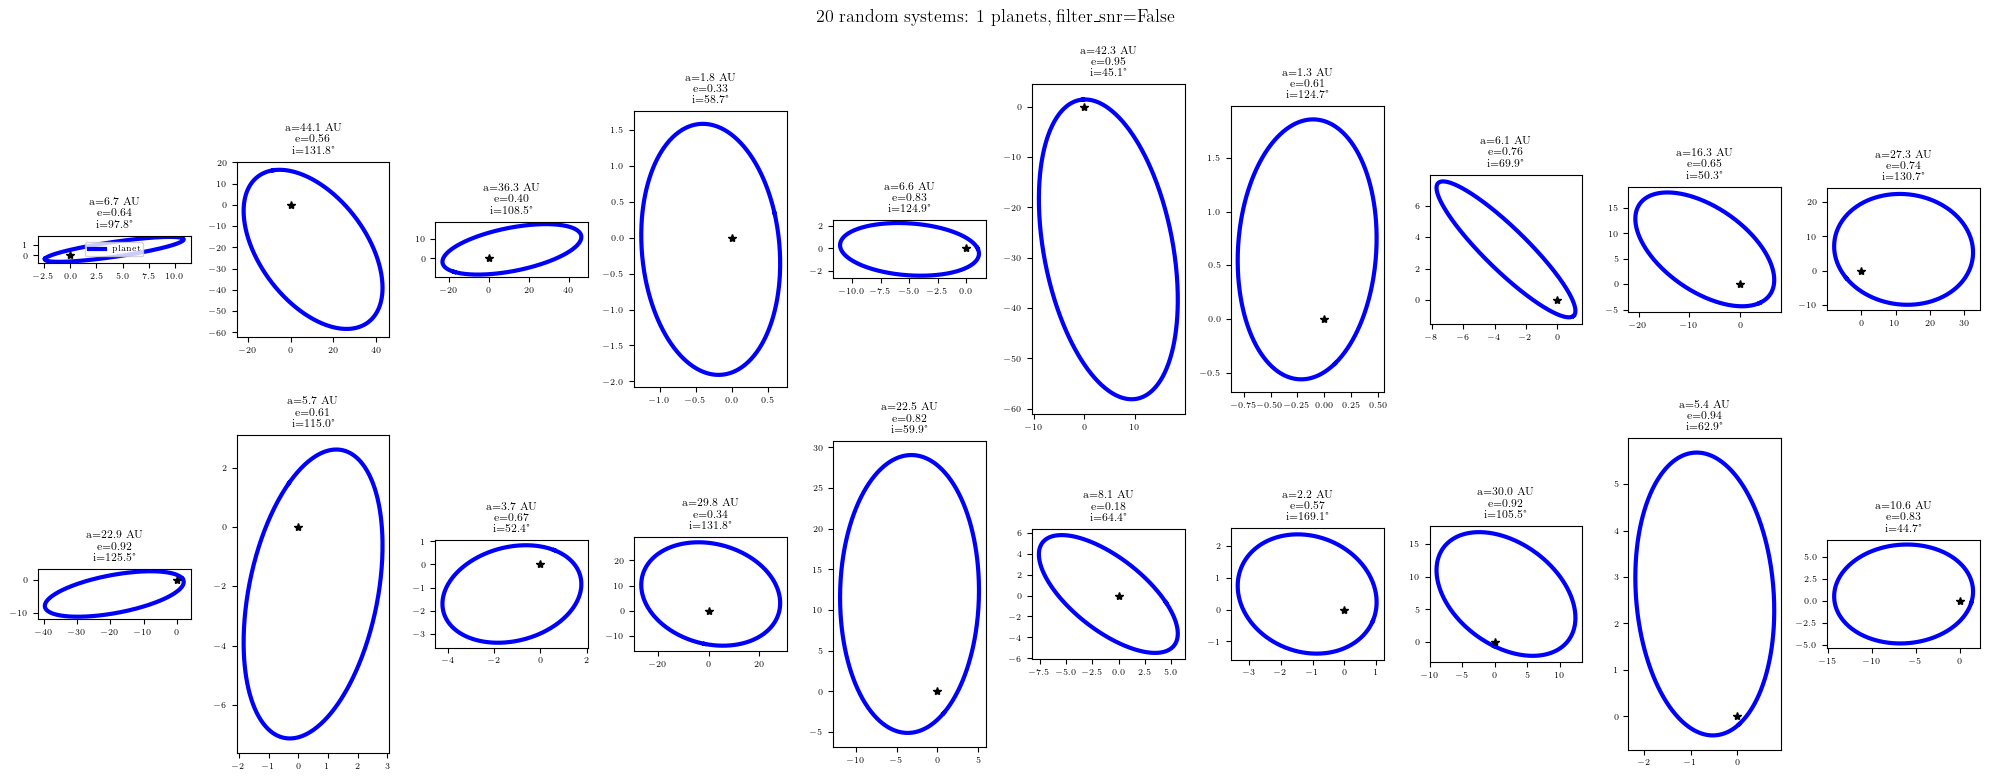

Saved figure: outputs/figures/20systems_1planets_agnostic_nosnrfilter.pdf

Generating 1-planet population | filter_snr=True


/var/folders/9z/bcj7jltn3x5_8y20r9cxql3h0000gn/T/ipykernel_48632/1590534189.py:36: DtypeWarning: Columns (0: fit_success_binary_msms, 1: fit_success_single_msms, 2: flag_extrap_m2_msms) have mixed types. Specify dtype option on import or set low_memory=False.
  catalog = pd.read_csv(star_catalog_path)


  processed 500 / 10667 stars
  processed 1000 / 10667 stars
  processed 1500 / 10667 stars
  processed 2000 / 10667 stars
  processed 2500 / 10667 stars
  processed 3000 / 10667 stars
  processed 3500 / 10667 stars
  processed 4000 / 10667 stars
  processed 4500 / 10667 stars
  processed 5000 / 10667 stars
  processed 5500 / 10667 stars
  processed 6000 / 10667 stars
  processed 6500 / 10667 stars
  processed 7000 / 10667 stars
  processed 7500 / 10667 stars
  processed 8000 / 10667 stars
  processed 8500 / 10667 stars
  processed 9000 / 10667 stars
  processed 9500 / 10667 stars
  processed 10000 / 10667 stars
  processed 10500 / 10667 stars
  processed 10667 / 10667 stars
Writing 10667 systems to outputs/data/agnostic_pop_1planet_snrfilter.csv
Saved: outputs/data/agnostic_pop_1planet_snrfilter.csv
Rows: 10667


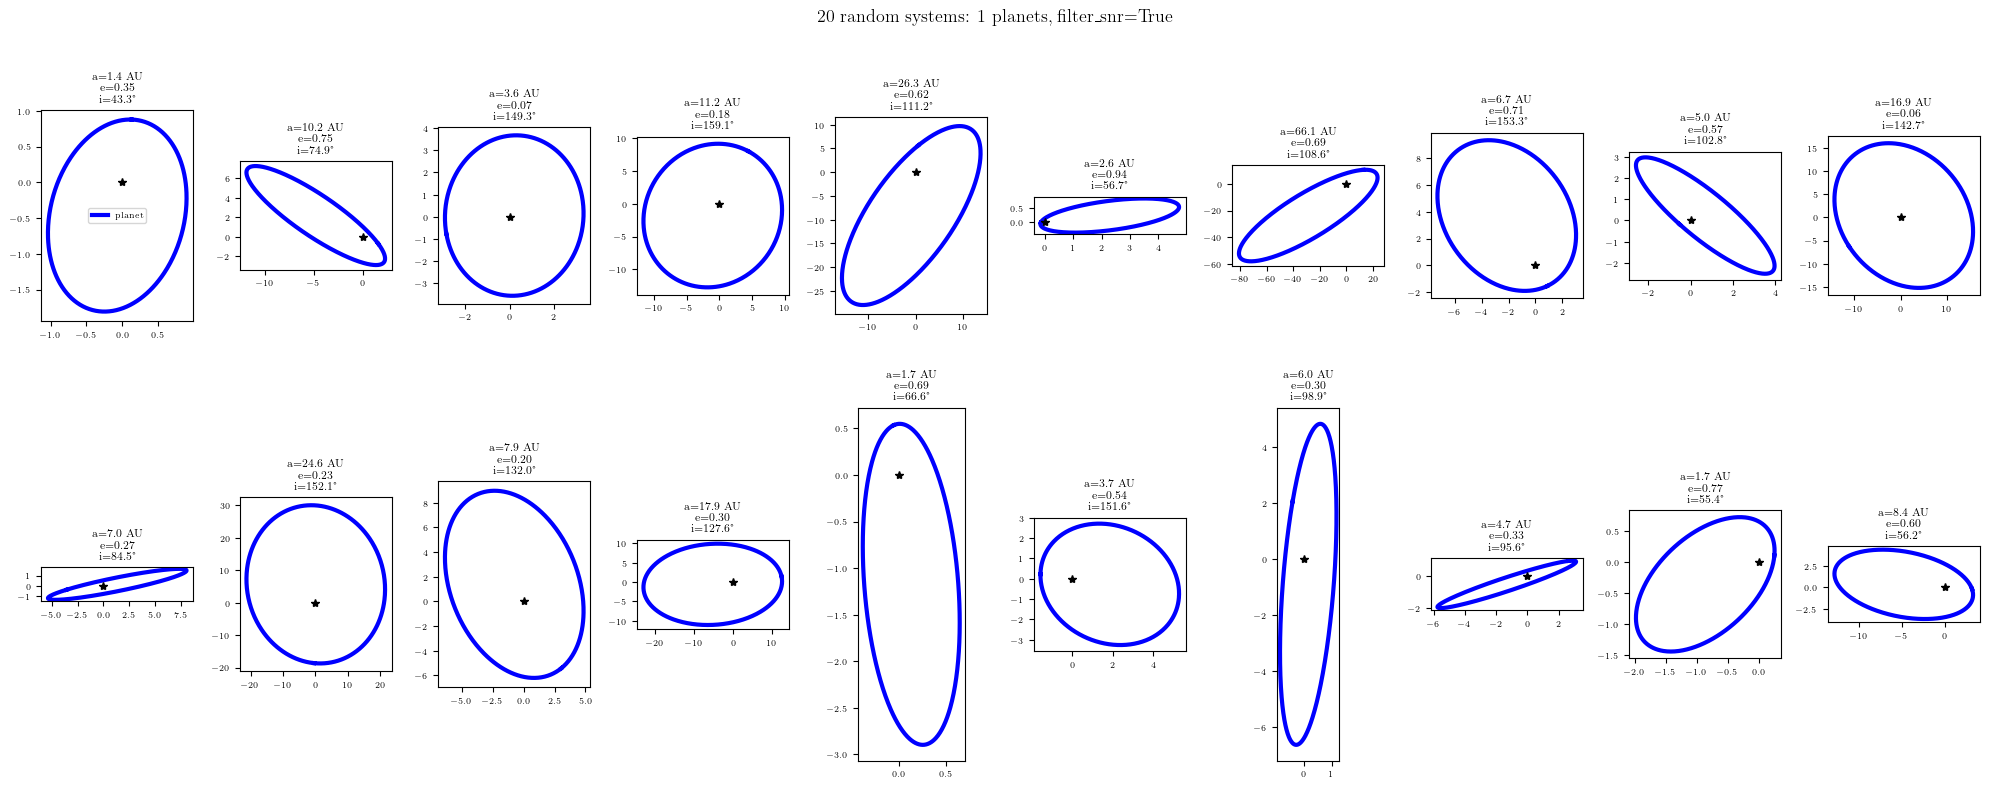

Saved figure: outputs/figures/20systems_1planets_agnostic_snrfilter.pdf

Generating 2-planet population | filter_snr=False
  processed 500 / 10667 stars
  processed 1000 / 10667 stars
  processed 1500 / 10667 stars
  processed 2000 / 10667 stars


/var/folders/9z/bcj7jltn3x5_8y20r9cxql3h0000gn/T/ipykernel_48632/1590534189.py:36: DtypeWarning: Columns (0: fit_success_binary_msms, 1: fit_success_single_msms, 2: flag_extrap_m2_msms) have mixed types. Specify dtype option on import or set low_memory=False.
  catalog = pd.read_csv(star_catalog_path)


  processed 2500 / 10667 stars
  processed 3000 / 10667 stars
  processed 3500 / 10667 stars
  processed 4000 / 10667 stars
  processed 4500 / 10667 stars
  processed 5000 / 10667 stars
  processed 5500 / 10667 stars
  processed 6000 / 10667 stars
  processed 6500 / 10667 stars
  processed 7000 / 10667 stars
  processed 7500 / 10667 stars
  processed 8000 / 10667 stars
  processed 8500 / 10667 stars
  processed 9000 / 10667 stars
  processed 9500 / 10667 stars
  processed 10000 / 10667 stars
  processed 10500 / 10667 stars
  processed 10667 / 10667 stars
Writing 10667 systems to outputs/data/agnostic_pop_2planet_nosnrfilter.csv
Saved: outputs/data/agnostic_pop_2planet_nosnrfilter.csv
Rows: 10667
33 / 10667 near resonance (0.3%)
  near 2:1: 19
  near 3:2: 14
          sma_1      sma_2   P_ratio  near_2_1  near_3_2
199    6.721146   8.912405  1.526959     False      True
468    2.423998   3.862328  2.011293      True     False
511    1.045840   1.361031  1.484582     False      True
1685

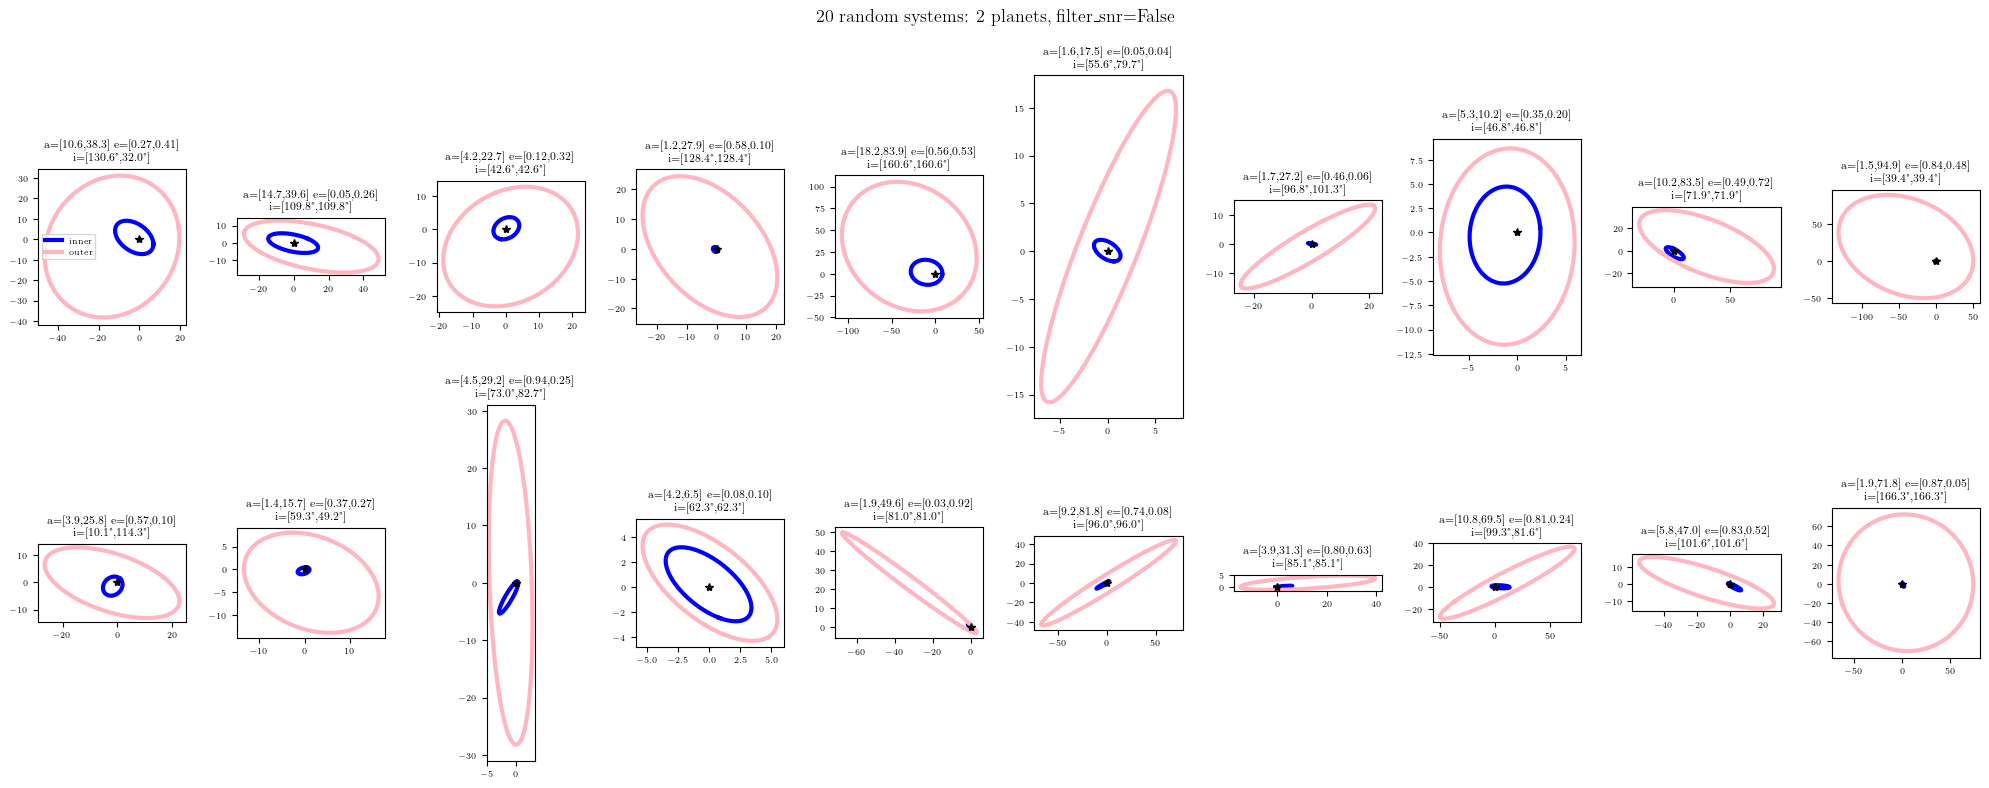

Saved figure: outputs/figures/20systems_2planets_agnostic_nosnrfilter.pdf

Generating 2-planet population | filter_snr=True


/var/folders/9z/bcj7jltn3x5_8y20r9cxql3h0000gn/T/ipykernel_48632/1590534189.py:36: DtypeWarning: Columns (0: fit_success_binary_msms, 1: fit_success_single_msms, 2: flag_extrap_m2_msms) have mixed types. Specify dtype option on import or set low_memory=False.
  catalog = pd.read_csv(star_catalog_path)


  processed 500 / 10667 stars
  processed 1000 / 10667 stars
  processed 1500 / 10667 stars
  processed 2000 / 10667 stars
  processed 2500 / 10667 stars
  processed 3000 / 10667 stars
  processed 3500 / 10667 stars
  processed 4000 / 10667 stars
  processed 4500 / 10667 stars
  processed 5000 / 10667 stars
  processed 5500 / 10667 stars
  processed 6000 / 10667 stars
  processed 6500 / 10667 stars
  processed 7000 / 10667 stars
  processed 7500 / 10667 stars
  processed 8000 / 10667 stars
  processed 8500 / 10667 stars
  processed 9000 / 10667 stars
  processed 9500 / 10667 stars
  processed 10000 / 10667 stars
  processed 10500 / 10667 stars
  processed 10667 / 10667 stars
Writing 10667 systems to outputs/data/agnostic_pop_2planet_snrfilter.csv
Saved: outputs/data/agnostic_pop_2planet_snrfilter.csv
Rows: 10667
274 / 10667 near resonance (2.6%)
  near 2:1: 197
  near 3:2: 77
        sma_1     sma_2   P_ratio  near_2_1  near_3_2
143  1.863349  2.991064  2.033748      True     False
190

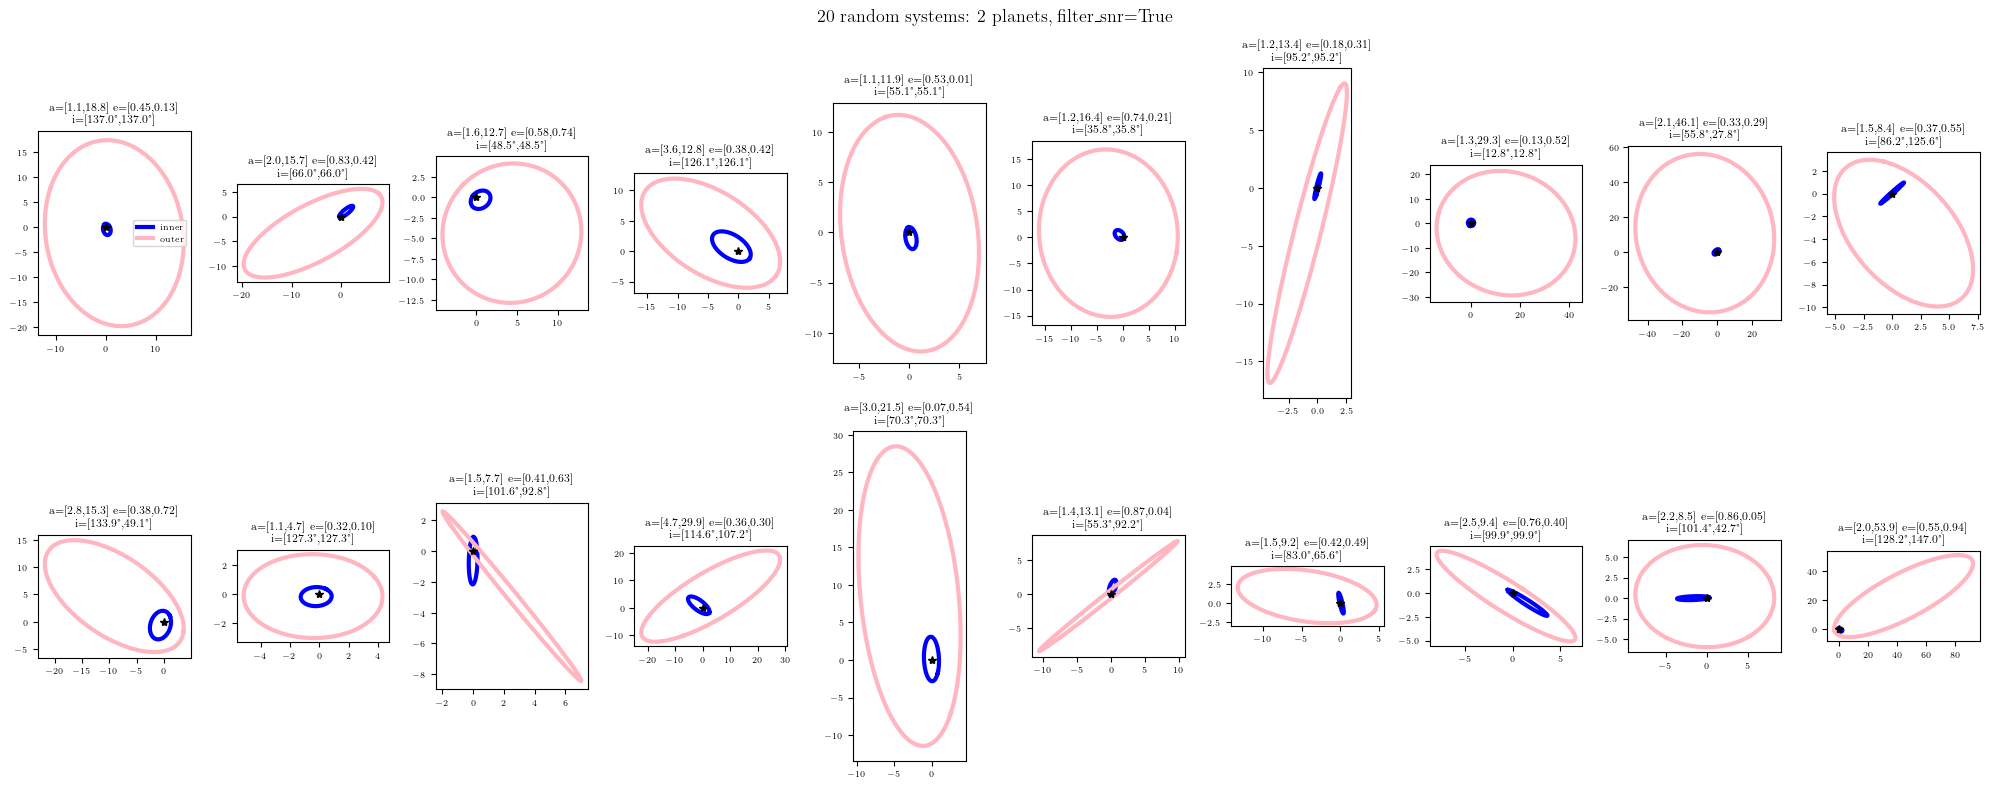

Saved figure: outputs/figures/20systems_2planets_agnostic_snrfilter.pdf


In [20]:
all_pop_dfs = run_all_orbit_populations()

In [17]:
# --------------------------------------------------
# Save population diagnostics plots
# --------------------------------------------------

os.makedirs("outputs/figures/", exist_ok=True)

# 1-planet diagnostics
plot_pop_diagnostics(
    ag_path="outputs/data/agnostic_pop_1planet_nosnrfilter.csv",
    snr_path="outputs/data/agnostic_pop_1planet_snrfilter.csv",
    output_path="outputs/figures/pop_diagnostics_1planet.pdf",
    n_planets=1,
)

# 2-planet diagnostics
plot_pop_diagnostics(
    ag_path="outputs/data/agnostic_pop_2planet_nosnrfilter.csv",
    snr_path="outputs/data/agnostic_pop_2planet_snrfilter.csv",
    output_path="outputs/figures/pop_diagnostics_2planet.pdf",
    n_planets=2,
)

Saved to outputs/figures/pop_diagnostics_1planet.pdf
Saved to outputs/figures/pop_diagnostics_2planet.pdf
